# **EDA with Raw Data**

In [57]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

plt.style.use('seaborn-v0_8-darkgrid')

sns.set_palette("Set2")

In [58]:
# Add src to path
sys.path.append(os.path.abspath("../"))
from src.data.load_data import load_data

df = load_data(show_info=True)

df.head()


📊 Dataset Loaded Successfully!
Shape: (30001, 25)

Columns:
['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14   

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [59]:
df.describe().T

,count,unique,top,freq
Unnamed: 0,30001,30001,ID,1
X1,30001,82,50000,3365
X2,30001,3,2,18112
X3,30001,8,2,14030
X4,30001,5,2,15964
X5,30001,57,29,1605
X6,30001,12,0,14737
X7,30001,12,0,15730
X8,30001,12,0,15764
X9,30001,12,0,16455


In [60]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))

Numerical Features: 0
Categorical Features: 25


# **Data Cleaning**

In [61]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [62]:
df.columns = [
    'Limit_Bal',
    'Gender',
    'Education',
    'Marriage',
    'Age',
    'RPay_stat_sep',
    'RPay_stat_aug',
    'RPay_stat_jul',
    'RPay_stat_jun',
    'RPay_stat_may',
    'RPay_stat_apr',
    'Bill_amt_sep',
    'Bill_amt_aug',
    'Bill_amt_jul',
    'Bill_amt_jun',
    'Bill_amt_may',
    'Bill_amt_apr',
    'Pay_amt_sep',
    'Pay_amt_aug',
    'Pay_amt_jul',
    'Pay_amt_jun',
    'Pay_amt_may',
    'Pay_amt_apr',
    'Default_Payment'
]

In [63]:
df = df.iloc[1:]  # Keeps all rows except index 0

In [64]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [65]:
df.dtypes

Limit_Bal          int64
Gender             int64
Education          int64
Marriage           int64
Age                int64
RPay_stat_sep      int64
RPay_stat_aug      int64
RPay_stat_jul      int64
RPay_stat_jun      int64
RPay_stat_may      int64
RPay_stat_apr      int64
Bill_amt_sep       int64
Bill_amt_aug       int64
Bill_amt_jul       int64
Bill_amt_jun       int64
Bill_amt_may       int64
Bill_amt_apr       int64
Pay_amt_sep        int64
Pay_amt_aug        int64
Pay_amt_jul        int64
Pay_amt_jun        int64
Pay_amt_may        int64
Pay_amt_apr        int64
Default_Payment    int64
dtype: object

In [66]:
df.isnull().sum()



Limit_Bal          0
Gender             0
Education          0
Marriage           0
Age                0
RPay_stat_sep      0
RPay_stat_aug      0
RPay_stat_jul      0
RPay_stat_jun      0
RPay_stat_may      0
RPay_stat_apr      0
Bill_amt_sep       0
Bill_amt_aug       0
Bill_amt_jul       0
Bill_amt_jun       0
Bill_amt_may       0
Bill_amt_apr       0
Pay_amt_sep        0
Pay_amt_aug        0
Pay_amt_jul        0
Pay_amt_jun        0
Pay_amt_may        0
Pay_amt_apr        0
Default_Payment    0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(35)

In [68]:
columns = ['Education', 'Marriage', 'Gender']
for col in columns:
    print(f"\n{col.upper()} counts:")
    print(df[col].value_counts().sort_index())


EDUCATION counts:
Education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE counts:
Marriage
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

GENDER counts:
Gender
1    11888
2    18112
Name: count, dtype: int64


Fix Invalid Categories

In [69]:
df['Education'] = df['Education'].replace([0,5,6],4)

df['Marriage'] = df['Marriage'].replace(0,3)

Target Variable Analysis

In [70]:
df['Default_Payment'].value_counts()

Default_Payment
0    23364
1     6636
Name: count, dtype: int64

In [71]:
df['Default_Payment'].value_counts(normalize=True) * 100

Default_Payment
0    77.88
1    22.12
Name: proportion, dtype: float64

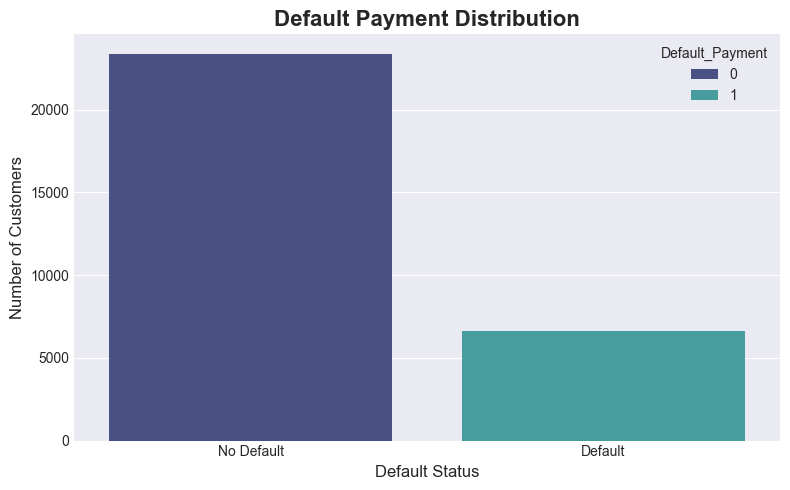

In [72]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Default_Payment',
    hue='Default_Payment',
    data=df,
    palette='mako',
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])



plt.title('Default Payment Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Default Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)



plt.tight_layout()
plt.show()

## Observation:
- The dataset is moderately imbalanced.
- Non-default clients represent the majority class.
- Therefore, metrics such as F1-score and ROC-AUC
  will be more informative than accuracy alone.

## **Saving Cleaned Data for Preprocessing**

In [73]:
import os

# Create data folder one level above notebooks
os.makedirs('../data/cleaned', exist_ok=True)

# Save cleaned dataset
df.to_csv(
    '../data/cleaned/credit_card_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# **EDA By Data Visualization**

## **Categorical Variables Analysis**

### **Create Readable Labels**

In [74]:
# Create readable copies for visualization only

cat_df = df.copy()

# Gender labels
cat_df['Gender_label'] = cat_df['Gender'].map({
    1: 'Male',
    2: 'Female'
})

# Education labels
cat_df['education_label'] = cat_df['Education'].map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others'
})

# Marriage labels
cat_df['marriage_label'] = cat_df['Marriage'].map({
    1: 'Married',
    2: 'Single',
    3: 'Others'
})

# Target labels
cat_df['default_label'] = cat_df['Default_Payment'].map({
    0: 'No Default',
    1: 'Default'
})

### **Dashboard 1: Categorical Feature Distributions**

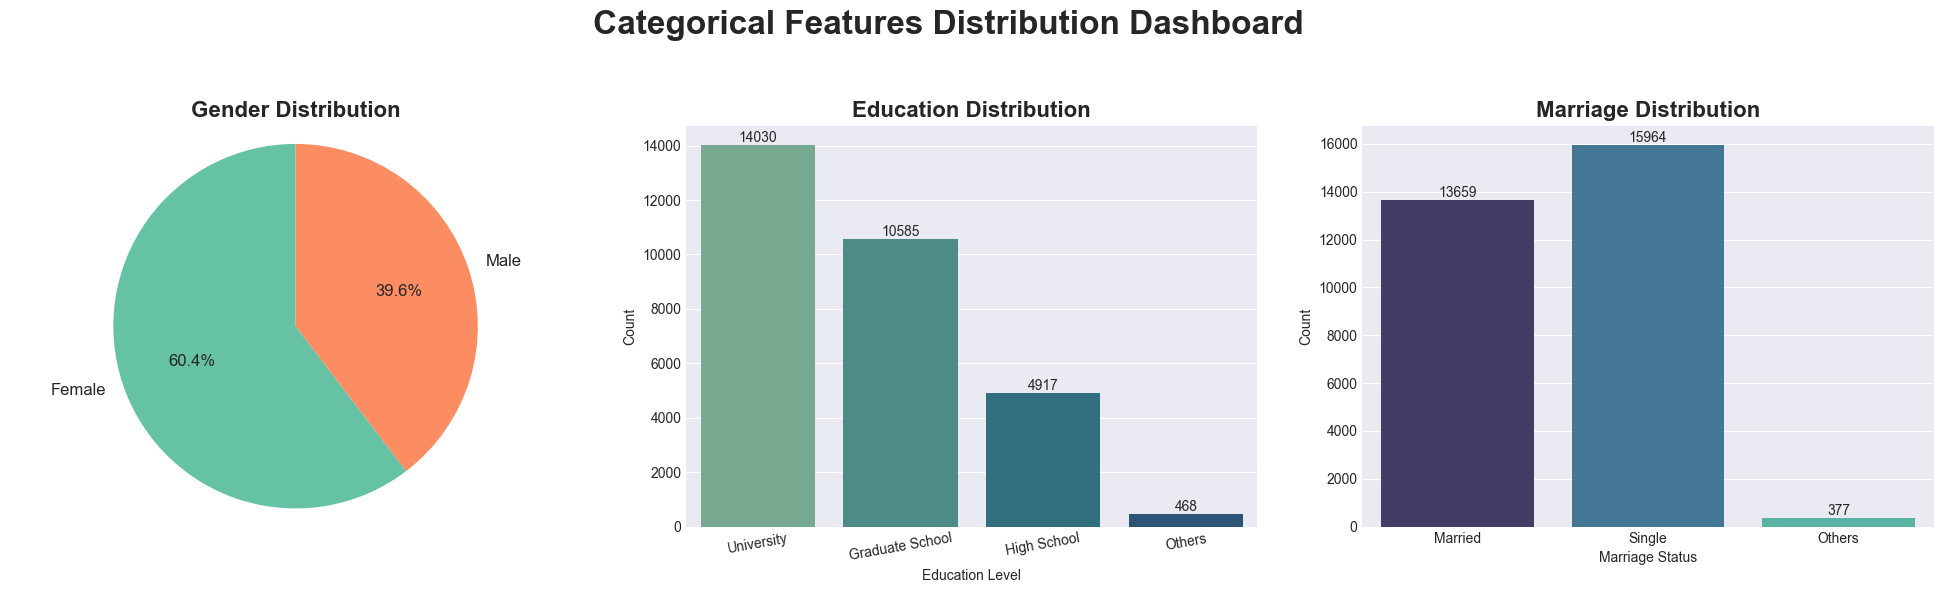

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    'Categorical Features Distribution Dashboard',
    fontsize=24,
    fontweight='bold'
)


# 1) Gender Distribution (Pie Chart)


gender_counts = cat_df['Gender_label'].value_counts()

axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)

axes[0].set_title(
    'Gender Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[0].axis('equal')


# 2) Education Distribution


sns.countplot(
    x='education_label',
    hue='education_label',
    data=cat_df,
    ax=axes[1],
    palette='crest'
)

axes[1].set_title(
    'Education Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Count')

axes[1].tick_params(axis='x', rotation=10)

for container in axes[1].containers:
    axes[1].bar_label(container)



# 3) Marriage Distribution


sns.countplot(
    x='marriage_label',
    hue='marriage_label',
    data=cat_df,
    ax=axes[2],
    palette='mako'
)

axes[2].set_title(
    'Marriage Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[2].set_xlabel('Marriage Status')
axes[2].set_ylabel('Count')

for container in axes[2].containers:
    axes[2].bar_label(container)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

### **Dashboard 2: Default Analysis Across Categories**

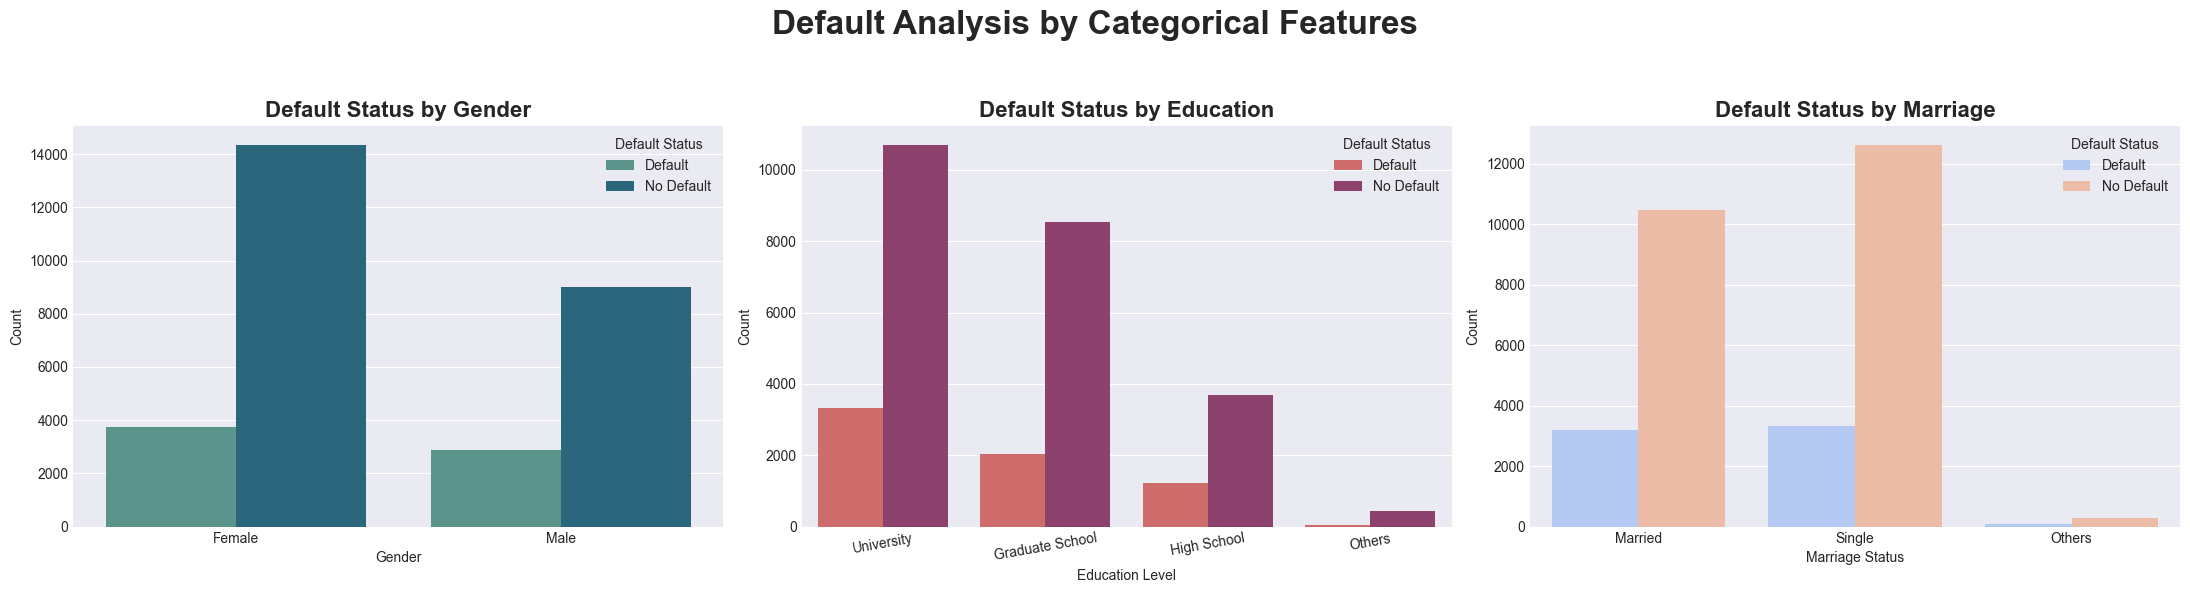

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(
    'Default Analysis by Categorical Features',
    fontsize=24,
    fontweight='bold'
)


# 1) Default Status by Gender

sns.countplot(
    x='Gender_label',
    hue='default_label',
    data=cat_df,
    ax=axes[0],
    palette='crest'
)

axes[0].set_title(
    'Default Status by Gender',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

axes[0].legend(title='Default Status')


# 2) Default Status by Education

sns.countplot(
    x='education_label',
    hue='default_label',
    data=cat_df,
    ax=axes[1],
    palette='flare'
)

axes[1].set_title(
    'Default Status by Education',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Count')

axes[1].tick_params(axis='x', rotation=10)

axes[1].legend(title='Default Status')


# 3) Default Status by Marriage

sns.countplot(
    x='marriage_label',
    hue='default_label',
    data=cat_df,
    ax=axes[2],
    palette='coolwarm'
)

axes[2].set_title(
    'Default Status by Marriage',
    fontsize=16,
    fontweight='bold'
)

axes[2].set_xlabel('Marriage Status')
axes[2].set_ylabel('Count')

axes[2].legend(title='Default Status')

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

## **Numerical Features Analysis**

### **Dashboard 1: Main Numerical Feature Distributions**

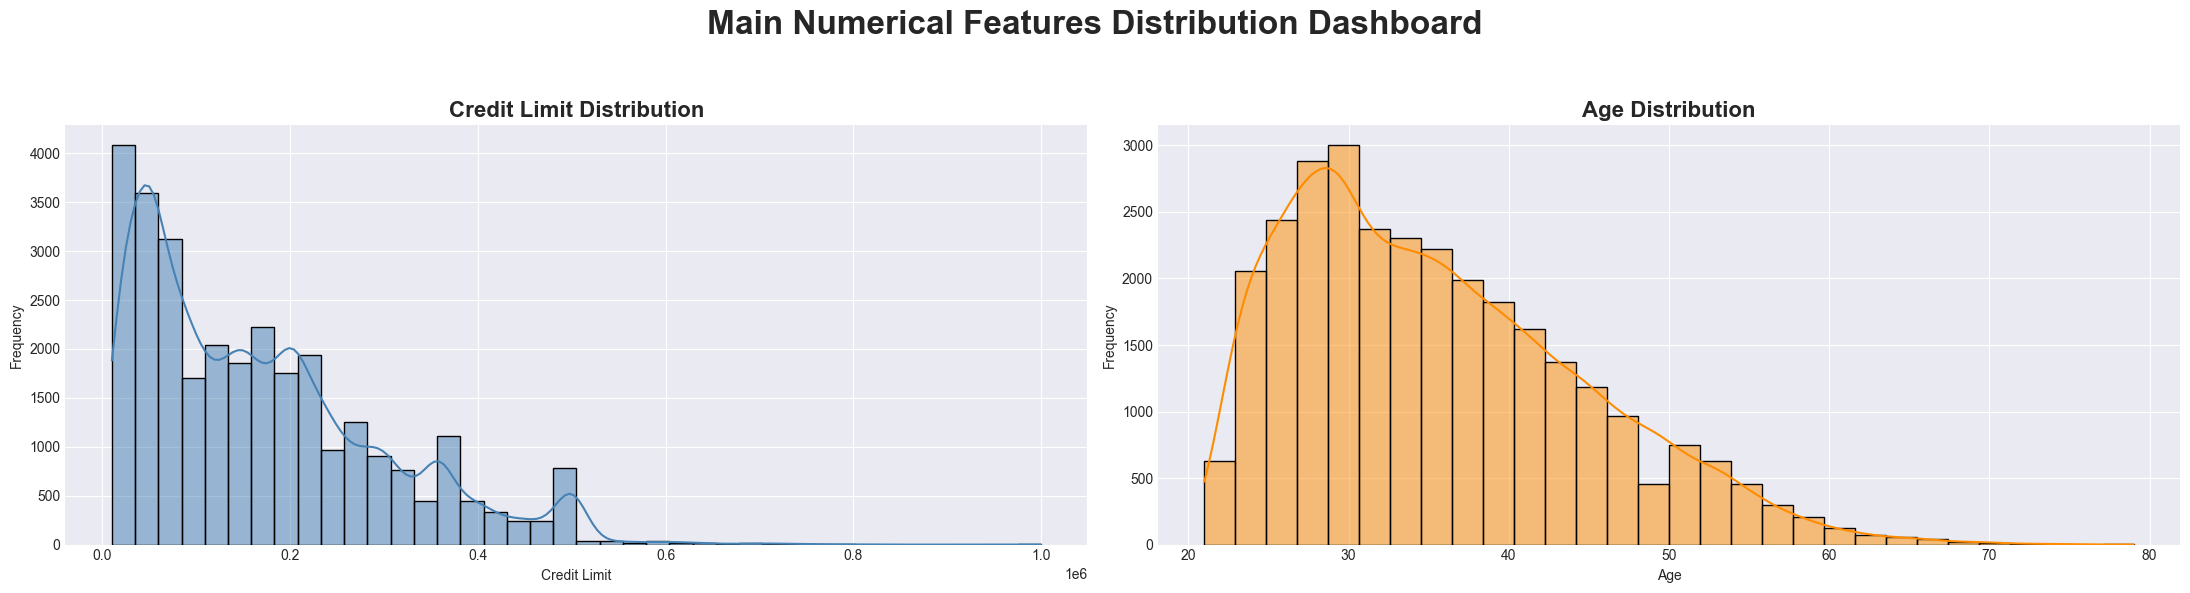

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

fig.suptitle(
    'Main Numerical Features Distribution Dashboard',
    fontsize=24,
    fontweight='bold'
)


# 1) Credit Limit Distribution


sns.histplot(
    df['Limit_Bal'],
    bins=40,
    kde=True,
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title(
    'Credit Limit Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_xlabel('Credit Limit')
axes[0].set_ylabel('Frequency')



# 2) Age Distribution


sns.histplot(
    df['Age'],
    bins=30,
    kde=True,
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title(
    'Age Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')


plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

### **Separate Other Numerical Feature Groups**

In [78]:
bill_cols = [
    'Bill_amt_sep',
    'Bill_amt_aug',
    'Bill_amt_jul',
    'Bill_amt_jun',
    'Bill_amt_may',
    'Bill_amt_apr'
]

pay_amt_cols = [
    'Pay_amt_sep',
    'Pay_amt_aug',
    'Pay_amt_jul',
    'Pay_amt_jun',
    'Pay_amt_may',
    'Pay_amt_apr'
]

pay_cols = [
    'RPay_stat_sep',
    'RPay_stat_aug',
    'RPay_stat_jul',
    'RPay_stat_jun',
    'RPay_stat_may',
    'RPay_stat_apr'
]

### **Customer Billing Behavior Analysis Dashboard**

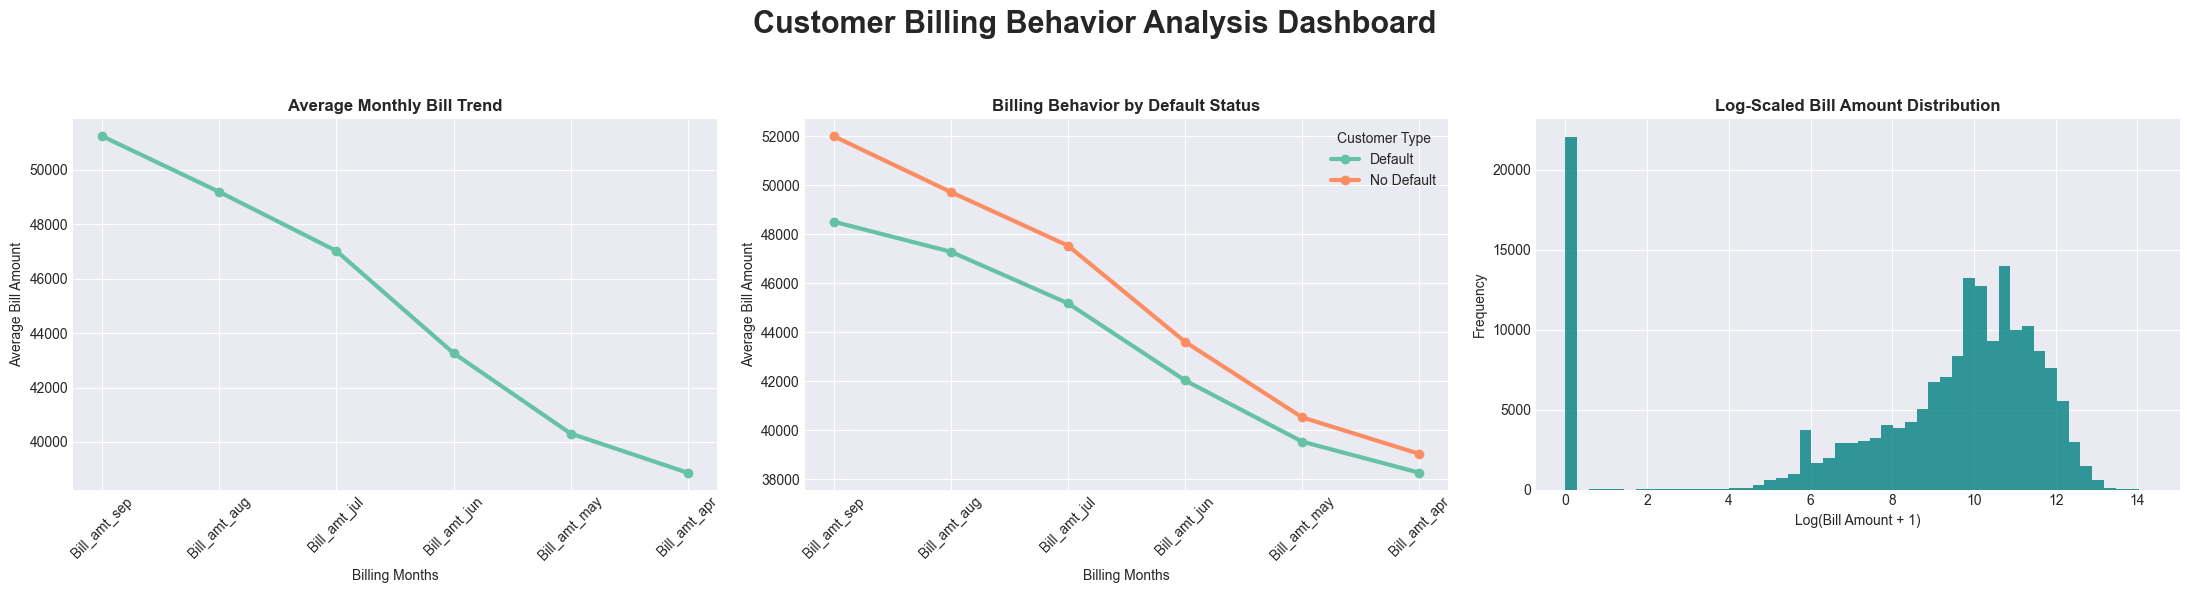

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(
    'Customer Billing Behavior Analysis Dashboard',
    fontsize=22,
    fontweight='bold'
)


# 1) Average Monthly Bill Trend


monthly_bill_avg = df[bill_cols].mean()

axes[0].plot(
    monthly_bill_avg.index,
    monthly_bill_avg.values,
    marker='o',
    linewidth=3
)

axes[0].set_title(
    'Average Monthly Bill Trend',
    fontweight='bold'
)

axes[0].set_xlabel('Billing Months')
axes[0].set_ylabel('Average Bill Amount')

axes[0].tick_params(axis='x', rotation=45)


# 2) Billing Behavior by Default Status


temp = df.copy()

temp['Default_Label'] = temp['Default_Payment'].map({
    0: 'No Default',
    1: 'Default'
})

bill_by_default = (
    temp
    .groupby('Default_Label')[bill_cols]
    .mean()
    .T
)

bill_by_default.plot(
    ax=axes[1],
    marker='o',
    linewidth=3
)

axes[1].set_title(
    'Billing Behavior by Default Status',
    fontweight='bold'
)

axes[1].set_xlabel('Billing Months')
axes[1].set_ylabel('Average Bill Amount')

axes[1].tick_params(axis='x', rotation=45)

axes[1].legend(title='Customer Type')


# 3) Log-Scaled Bill Distribution


axes[2].hist(
    np.log1p(
        df[bill_cols]
        .clip(lower=0)
        .values
        .flatten()
    ),
    bins=50,
    color='teal',
    alpha=0.8
)

axes[2].set_title(
    'Log-Scaled Bill Amount Distribution',
    fontweight='bold'
)

axes[2].set_xlabel('Log(Bill Amount + 1)')
axes[2].set_ylabel('Frequency')


# Layout


plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

### **Repayment Behavior Analysis Dashboard**

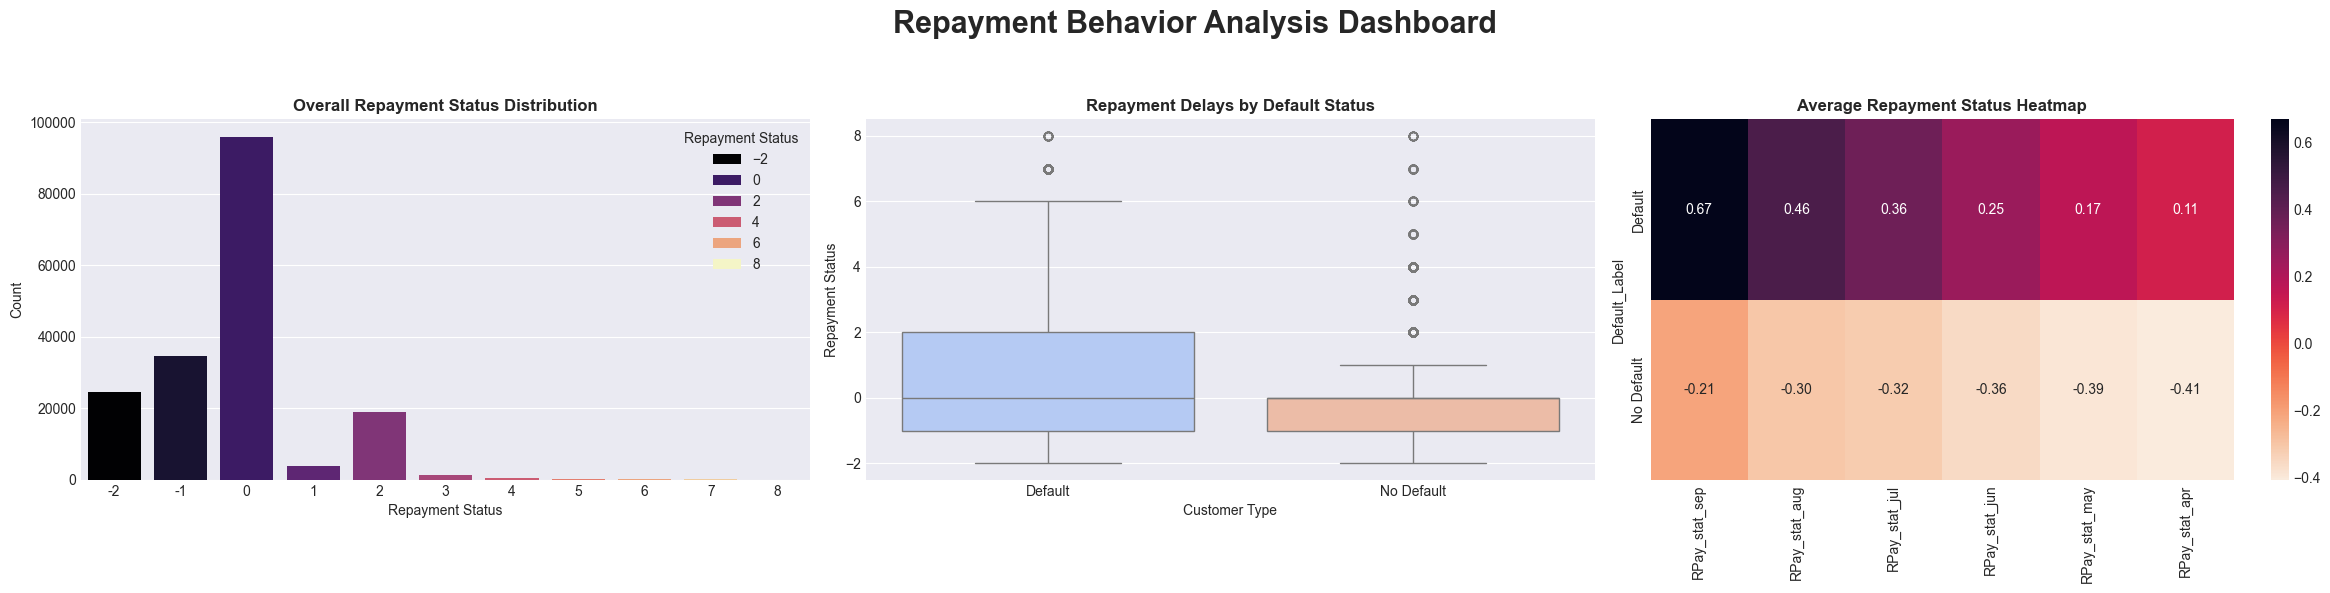

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

fig.suptitle(
    'Repayment Behavior Analysis Dashboard',
    fontsize=22,
    fontweight='bold'
)



# 1) Overall Repayment Status Distribution


pay_melted = df[pay_cols].melt(
    var_name='Month',
    value_name='Repayment Status'
)

sns.countplot(
    x='Repayment Status',
    hue='Repayment Status',
    data=pay_melted,
    palette='magma',
    ax=axes[0]
)

axes[0].set_title(
    'Overall Repayment Status Distribution',
    fontweight='bold'
)

axes[0].set_xlabel('Repayment Status')
axes[0].set_ylabel('Count')



# 2) Repayment Status by Default Behavior


repayment_default = temp.melt(
    id_vars='Default_Label',
    value_vars=pay_cols,
    var_name='Month',
    value_name='Repayment Status'
)

sns.boxplot(
    x='Default_Label',
    hue='Default_Label',
    y='Repayment Status',
    data=repayment_default,
    palette='coolwarm',
    ax=axes[1]
)

axes[1].set_title(
    'Repayment Delays by Default Status',
    fontweight='bold'
)

axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Repayment Status')



# 3) Average Repayment Trend Heatmap


pay_heatmap = (
    temp
    .groupby('Default_Label')[pay_cols]
    .mean()
)

sns.heatmap(
    pay_heatmap,
    annot=True,
    cmap='rocket_r',
    fmt='.2f',
    ax=axes[2]
)

axes[2].set_title(
    'Average Repayment Status Heatmap',
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

### **Customer Payment Behavior Dashboard**

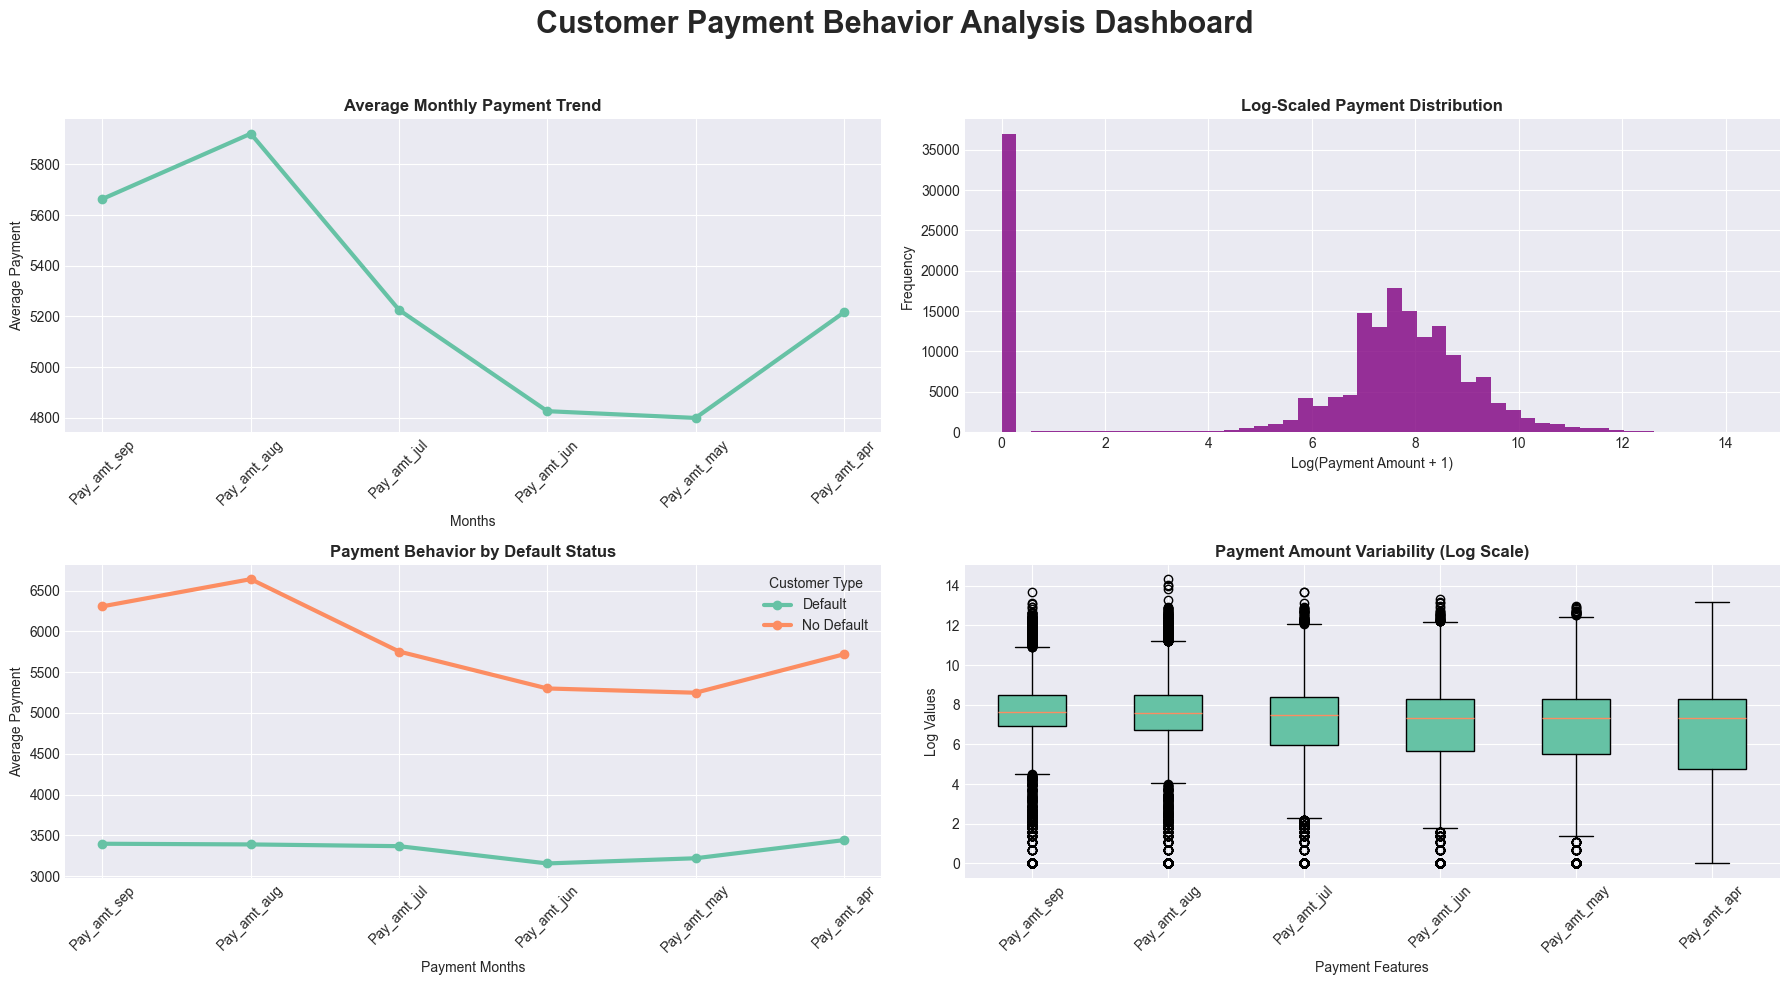

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

fig.suptitle(
    'Customer Payment Behavior Analysis Dashboard',
    fontsize=22,
    fontweight='bold'
)


# 1) Average Monthly Payment Trend


monthly_avg = df[pay_amt_cols].mean()

axes[0,0].plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    linewidth=3
)

axes[0,0].set_title(
    'Average Monthly Payment Trend',
    fontweight='bold'
)

axes[0,0].set_xlabel('Months')
axes[0,0].set_ylabel('Average Payment')

axes[0,0].tick_params(axis='x', rotation=45)



# 2) Log-Scaled Distribution (ALL PAY_AMT combined view)


axes[0,1].hist(
    np.log1p(df[pay_amt_cols].values.flatten()),
    bins=50,
    color='purple',
    alpha=0.8
)

axes[0,1].set_title(
    'Log-Scaled Payment Distribution',
    fontweight='bold'
)

axes[0,1].set_xlabel('Log(Payment Amount + 1)')
axes[0,1].set_ylabel('Frequency')



# 3) Default vs Non-Default Payment Behavior


temp = df.copy()
temp['Default_Label'] = temp['Default_Payment'].map({
    0: 'No Default',
    1: 'Default'
})

payment_by_default = temp.groupby('Default_Label')[pay_amt_cols].mean().T

payment_by_default.plot(
    ax=axes[1,0],
    marker='o',
    linewidth=3
)

axes[1,0].set_title(
    'Payment Behavior by Default Status',
    fontweight='bold'
)

axes[1,0].set_xlabel('Payment Months')
axes[1,0].set_ylabel('Average Payment')

axes[1,0].tick_params(axis='x', rotation=45)

axes[1,0].legend(title='Customer Type')



# 4) Boxplot Summary (NEW INSIGHT)


axes[1,1].boxplot(
    np.log1p(df[pay_amt_cols]),
    patch_artist=True
)

axes[1,1].set_title(
    'Payment Amount Variability (Log Scale)',
    fontweight='bold'
)

axes[1,1].set_xlabel('Payment Features')
axes[1,1].set_ylabel('Log Values')

axes[1,1].set_xticklabels(pay_amt_cols, rotation=45)



# Layout


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

## **Correlation Analysis**

In [82]:
corr_matrix = df.corr()

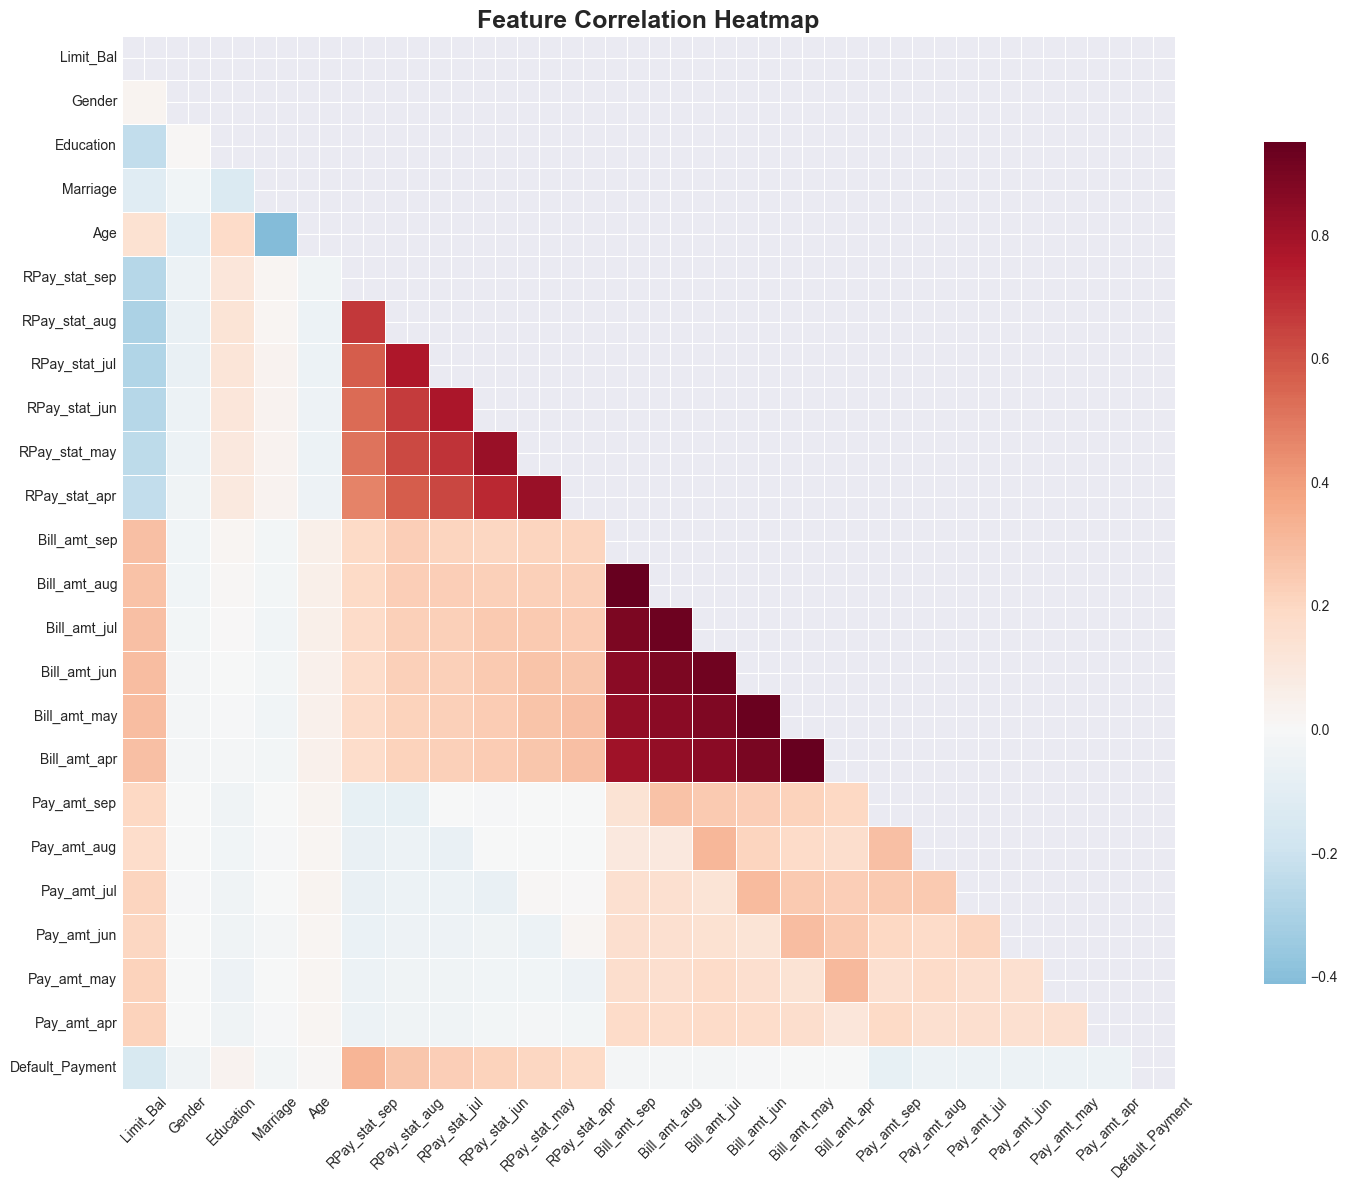

In [83]:
plt.figure(figsize=(18, 12))

corr_matrix = df.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [84]:
target_corr = corr_matrix['Default_Payment'].sort_values(ascending=False)

target_corr

Default_Payment    1.000000
RPay_stat_sep      0.324794
RPay_stat_aug      0.263551
RPay_stat_jul      0.235253
RPay_stat_jun      0.216614
RPay_stat_may      0.204149
RPay_stat_apr      0.186866
Education          0.033842
Age                0.013890
Bill_amt_apr      -0.005372
Bill_amt_may      -0.006760
Bill_amt_jun      -0.010156
Bill_amt_jul      -0.014076
Bill_amt_aug      -0.014193
Bill_amt_sep      -0.019644
Marriage          -0.027575
Gender            -0.039961
Pay_amt_apr       -0.053183
Pay_amt_may       -0.055124
Pay_amt_jul       -0.056250
Pay_amt_jun       -0.056827
Pay_amt_aug       -0.058579
Pay_amt_sep       -0.072929
Limit_Bal         -0.153520
Name: Default_Payment, dtype: float64

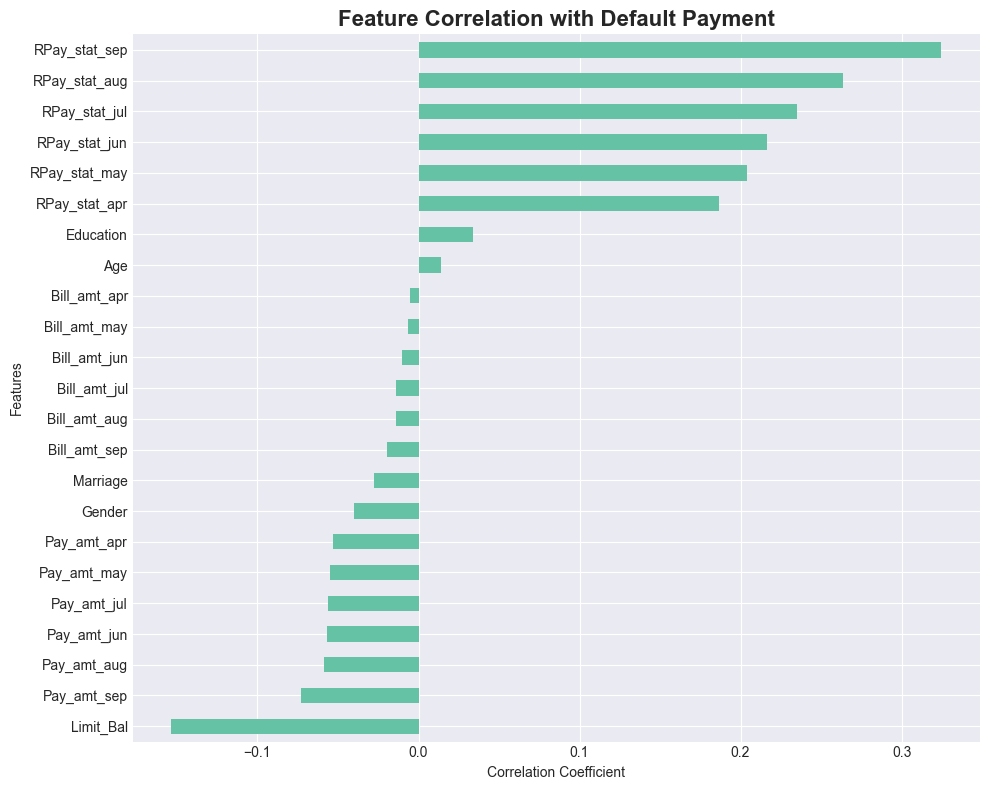

In [85]:
target_corr = (
    corr_matrix['Default_Payment']
    .drop('Default_Payment')
    .sort_values()
)

plt.figure(figsize=(10, 8))

target_corr.plot(kind='barh')

plt.title(
    'Feature Correlation with Default Payment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Correlation Coefficient')

plt.ylabel('Features')

plt.tight_layout()

plt.show()